In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql.functions import col, to_date, year
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [2]:
# =========================
# GCP Configuration
# =========================
PROJECT_ID = "my-project-xxxx"
REGION = "us-east1"

SERVICE_ACCOUNT = "name@project.iam.gserviceaccount.com"

CSV_FILE_PATH = "gs://dataproc-metastore-public-binaries/asset_price_forecast/asset_price_forecast.csv"

# =========================
# Iceberg Configuration
# =========================
ICEBERG_CATALOG = "biglake"
ICEBERG_SCHEMA = "finance"
ICEBERG_TABLE = "asset_prices"
ICEBERG_WAREHOUSE = "gs://your-bucket/iceberg/"

# =========================
# Forecast Config
# =========================
MODEL_NAME = "prophet"
FORECAST_HORIZON_DAYS = 30
TEST_SIZE = 0.2

In [3]:
from google.cloud.dataproc_v1 import EnvironmentConfig, ExecutionConfig, Session
from google.cloud.dataproc_spark_connect import DataprocSparkSession

session = Session()

session.runtime_config = {
    "version": "3.0",
    "properties": {
        "spark.driver.cores": "4",
        "spark.driver.memory": "4g",
        "spark.driver.memoryOverhead": "1g",
        "spark.executor.cores": "4",
        "spark.executor.memory": "4g",
        "spark.executor.memoryOverhead": "1g",
        "spark.executor.instances": "2",
        "spark.dataproc.engine": "default",
        f"spark.sql.catalog.{ICEBERG_CATALOG}": "org.apache.iceberg.spark.SparkCatalog",
        f"spark.sql.catalog.{ICEBERG_CATALOG}.type": "hadoop",
        f"spark.sql.catalog.{ICEBERG_CATALOG}.warehouse": ICEBERG_WAREHOUSE,
    },
}

execution_config = ExecutionConfig()
execution_config.service_account = SERVICE_ACCOUNT

environment_config = EnvironmentConfig()
environment_config.execution_config = execution_config
session.environment_config = environment_config

spark = (
    DataprocSparkSession.builder
    .projectId(PROJECT_ID)
    .location(REGION)
    .dataprocSessionConfig(session)
    .getOrCreate()
)

print("Dataproc Serverless Spark session created successfully.")

C:\Users\wizar\miniconda3\envs\Hognose\Lib\site-packages\google\cloud\dataproc_spark_connect\session.py:336: UserWarning: Python version mismatch detected: Client is using Python 3.13, but Dataproc runtime 3.0 uses Python 3.12. This mismatch may cause issues with Python UDF (User Defined Function) compatibility. Consider using Python 3.12 for optimal UDF execution.
  dataproc_config: Session = self._get_dataproc_config()


███████████████████████████▋                                                    

Dataproc Serverless Spark session created successfully.


In [4]:
raw_prices_sdf = (
    spark.read.format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .load(CSV_FILE_PATH)
)

print("Raw schema:")
raw_prices_sdf.printSchema()

raw_prices_sdf.show(5, truncate=False)

Raw schema:
root
 |-- Date: date (nullable = true)
 |-- Close: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Volume: integer (nullable = true)



  0%|                                                                                                         …

+----------+------------------+------------------+------------------+------------------+------+
|Date      |Close             |High              |Low               |Open              |Volume|
+----------+------------------+------------------+------------------+------------------+------+
|2019-07-22|1425.300048828125 |1425.300048828125 |1424.0            |1425.300048828125 |1     |
|2019-07-23|1420.0999755859375|1421.300048828125 |1416.300048828125 |1418.5999755859375|5     |
|2019-07-24|1422.800048828125 |1422.800048828125 |1422.800048828125 |1422.800048828125 |20    |
|2019-07-25|1413.9000244140625|1413.9000244140625|1413.9000244140625|1413.9000244140625|4     |
|2019-07-26|1418.5            |1423.0            |1418.5            |1422.800048828125 |5     |
+----------+------------------+------------------+------------------+------------------+------+
only showing top 5 rows


In [5]:
required_columns = ["Date", "Close"]

missing_columns = [column_name for column_name in required_columns if column_name not in raw_prices_sdf.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Required columns are present.")

Required columns are present.


In [6]:
clean_prices_sdf = (
    raw_prices_sdf
    .withColumnRenamed("Date", "trade_date")
    .withColumnRenamed("Close", "closing_price")
    .withColumn("trade_date", to_date(col("trade_date")))
    .select("trade_date", "closing_price")
    .dropna()
    .withColumn("year", year(col("trade_date")))
    .orderBy("trade_date")
)

print("Cleaned schema:")
clean_prices_sdf.printSchema()

clean_prices_sdf.show(5, truncate=False)

Cleaned schema:
root
 |-- trade_date: date (nullable = true)
 |-- closing_price: double (nullable = true)
 |-- year: integer (nullable = true)



  0%|                                                                                                         …

+----------+------------------+----+
|trade_date|closing_price     |year|
+----------+------------------+----+
|2019-07-22|1425.300048828125 |2019|
|2019-07-23|1420.0999755859375|2019|
|2019-07-24|1422.800048828125 |2019|
|2019-07-25|1413.9000244140625|2019|
|2019-07-26|1418.5            |2019|
+----------+------------------+----+
only showing top 5 rows


In [7]:
iceberg_table_name = f"{ICEBERG_CATALOG}.{ICEBERG_SCHEMA}.{ICEBERG_TABLE}"

clean_prices_sdf.writeTo(iceberg_table_name).using("iceberg").createOrReplace()

print(f"Data written to Iceberg table: {iceberg_table_name}")

  0%|                                                                                                         …

Data written to Iceberg table: biglake.finance.asset_prices


In [8]:
iceberg_prices_sdf = spark.read.table(iceberg_table_name)

print("Iceberg sample rows:")
iceberg_prices_sdf.show(5, truncate=False)

Iceberg sample rows:


  0%|                                                                                                         …

+----------+------------------+----+
|trade_date|closing_price     |year|
+----------+------------------+----+
|2019-07-22|1425.300048828125 |2019|
|2019-07-23|1420.0999755859375|2019|
|2019-07-24|1422.800048828125 |2019|
|2019-07-25|1413.9000244140625|2019|
|2019-07-26|1418.5            |2019|
+----------+------------------+----+
only showing top 5 rows


In [9]:
forecast_input_pdf = (
    iceberg_prices_sdf
    .select("trade_date", "closing_price")
    .toPandas()
    .rename(columns={
        "trade_date": "forecast_date",
        "closing_price": "actual_price"
    })
)

forecast_input_pdf["forecast_date"] = pd.to_datetime(forecast_input_pdf["forecast_date"])
forecast_input_pdf = forecast_input_pdf.sort_values("forecast_date").reset_index(drop=True)

forecast_input_pdf.head()

  0%|                                                                                                         …

,forecast_date,actual_price
0,2019-07-22,1425.300049
1,2019-07-23,1420.099976
2,2019-07-24,1422.800049
3,2019-07-25,1413.900024
4,2019-07-26,1418.500000


In [10]:
split_index = int(len(forecast_input_pdf) * (1 - TEST_SIZE))

train_prices_pdf = forecast_input_pdf.iloc[:split_index].copy()
test_prices_pdf = forecast_input_pdf.iloc[split_index:].copy()

print("Training rows:", len(train_prices_pdf))
print("Testing rows:", len(test_prices_pdf))

Training rows: 1206
Testing rows: 302


In [11]:
last_observed_price = train_prices_pdf["actual_price"].iloc[-1]

naive_baseline_forecast_pdf = pd.DataFrame({
    "forecast_date": test_prices_pdf["forecast_date"].values,
    "actual_price": test_prices_pdf["actual_price"].values,
    "predicted_price": [last_observed_price] * len(test_prices_pdf),
    "model_name": "naive_baseline"
})

naive_baseline_forecast_pdf.head()

,forecast_date,actual_price,predicted_price,model_name
0,2024-05-06,2321.600098,2299.0,naive_baseline
1,2024-05-07,2315.199951,2299.0,naive_baseline
2,2024-05-08,2313.600098,2299.0,naive_baseline
3,2024-05-09,2332.100098,2299.0,naive_baseline
4,2024-05-10,2367.300049,2299.0,naive_baseline


In [12]:
prophet_train_pdf = train_prices_pdf.rename(columns={
    "forecast_date": "ds",
    "actual_price": "y"
})[["ds", "y"]]

prophet_test_pdf = test_prices_pdf.rename(columns={
    "forecast_date": "ds",
    "actual_price": "y"
})[["ds", "y"]]

In [13]:
prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train_pdf)

print("Prophet model trained successfully.")

INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing


Prophet model trained successfully.


In [14]:
future_test_dates_pdf = prophet_test_pdf[["ds"]].copy()

prophet_predictions_pdf = prophet_model.predict(future_test_dates_pdf)

prophet_forecast_pdf = pd.DataFrame({
    "forecast_date": prophet_test_pdf["ds"].values,
    "actual_price": prophet_test_pdf["y"].values,
    "predicted_price": prophet_predictions_pdf["yhat"].values,
    "model_name": "prophet"
})

prophet_forecast_pdf.head()

,forecast_date,actual_price,predicted_price,model_name
0,2024-05-06,2321.600098,2243.661724,prophet
1,2024-05-07,2315.199951,2244.385982,prophet
2,2024-05-08,2313.600098,2243.778918,prophet
3,2024-05-09,2332.100098,2245.113782,prophet
4,2024-05-10,2367.300049,2244.616032,prophet


In [15]:
def calculate_mae(actual_values, predicted_values):
    return float(np.mean(np.abs(actual_values - predicted_values)))

def calculate_mse(actual_values, predicted_values):
    return float(np.mean((actual_values - predicted_values) ** 2))

def calculate_rmse(actual_values, predicted_values):
    return float(np.sqrt(calculate_mse(actual_values, predicted_values)))

def calculate_mape(actual_values, predicted_values):
    non_zero_mask = actual_values != 0

    if not non_zero_mask.any():
        return float("nan")

    filtered_actual_values = actual_values[non_zero_mask]
    filtered_predicted_values = predicted_values[non_zero_mask]

    return float(
        np.mean(np.abs((filtered_actual_values - filtered_predicted_values) / filtered_actual_values)) * 100
    )

def evaluate_forecast(forecast_results_pdf):
    return {
        "model_name": forecast_results_pdf["model_name"].iloc[0],
        "mae": calculate_mae(
            forecast_results_pdf["actual_price"],
            forecast_results_pdf["predicted_price"]
        ),
        "mse": calculate_mse(
            forecast_results_pdf["actual_price"],
            forecast_results_pdf["predicted_price"]
        ),
        "rmse": calculate_rmse(
            forecast_results_pdf["actual_price"],
            forecast_results_pdf["predicted_price"]
        ),
        "mape": calculate_mape(
            forecast_results_pdf["actual_price"],
            forecast_results_pdf["predicted_price"]
        ),
    }

In [16]:
evaluation_summary_pdf = pd.DataFrame([
    evaluate_forecast(naive_baseline_forecast_pdf),
    evaluate_forecast(prophet_forecast_pdf)
]).sort_values("rmse").reset_index(drop=True)

evaluation_summary_pdf

,model_name,mae,mse,rmse,mape
0,prophet,441.222461,251012.517875,501.011495,15.092703
1,naive_baseline,480.380793,351347.924068,592.746087,16.028191


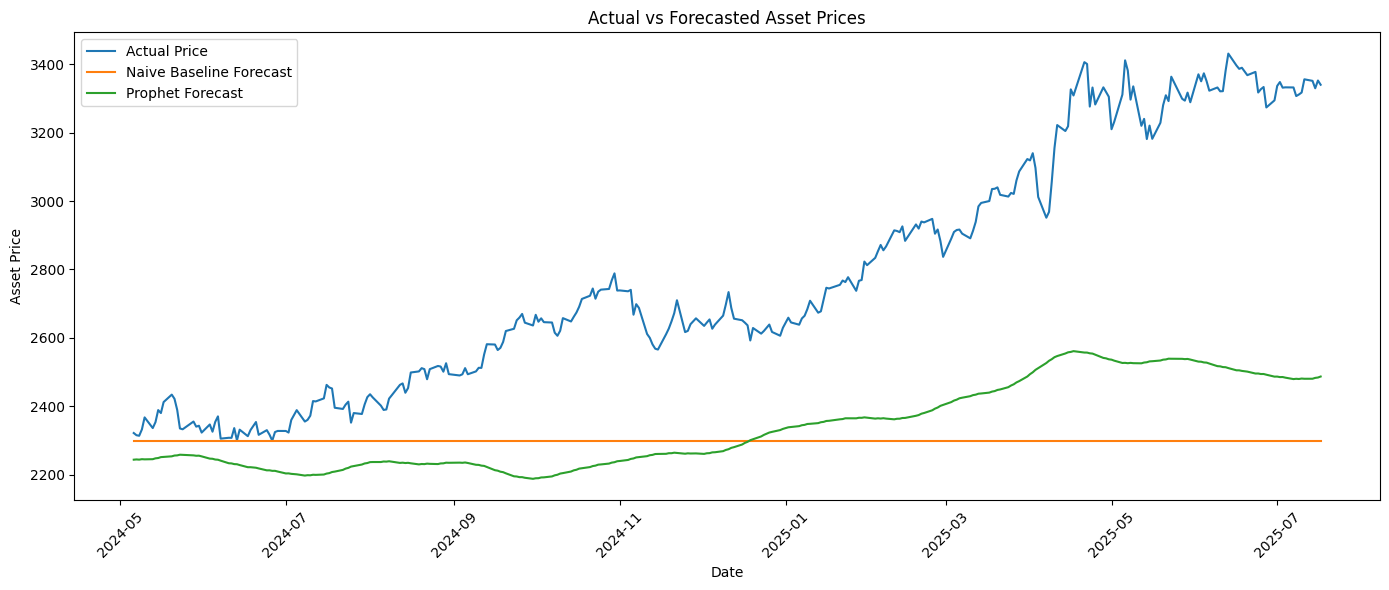

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_prices_pdf["forecast_date"],
    test_prices_pdf["actual_price"],
    label="Actual Price"
)

plt.plot(
    naive_baseline_forecast_pdf["forecast_date"],
    naive_baseline_forecast_pdf["predicted_price"],
    label="Naive Baseline Forecast"
)

plt.plot(
    prophet_forecast_pdf["forecast_date"],
    prophet_forecast_pdf["predicted_price"],
    label="Prophet Forecast"
)

plt.title("Actual vs Forecasted Asset Prices")
plt.xlabel("Date")
plt.ylabel("Asset Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
full_prophet_input_pdf = forecast_input_pdf.rename(columns={
    "forecast_date": "ds",
    "actual_price": "y"
})[["ds", "y"]]

final_prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

final_prophet_model.fit(full_prophet_input_pdf)

future_dates_pdf = final_prophet_model.make_future_dataframe(periods=FORECAST_HORIZON_DAYS)

future_forecast_pdf = final_prophet_model.predict(future_dates_pdf)

future_forecast_pdf[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(FORECAST_HORIZON_DAYS)

INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1508,2025-07-18,3342.205254,3276.457823,3400.999279
1509,2025-07-19,3318.008375,3251.699875,3381.104622
1510,2025-07-20,3321.179514,3255.600190,3385.721830
1511,2025-07-21,3349.573005,3286.104482,3412.371846
1512,2025-07-22,3355.271451,3292.120893,3421.137733
1513,2025-07-23,3359.440065,3298.222733,3419.859509
1514,2025-07-24,3363.156286,3297.506875,3426.590504
1515,2025-07-25,3365.351024,3304.045541,3427.146672
1516,2025-07-26,3341.584083,3278.762156,3402.156132
1517,2025-07-27,3345.122588,3284.278335,3411.000140


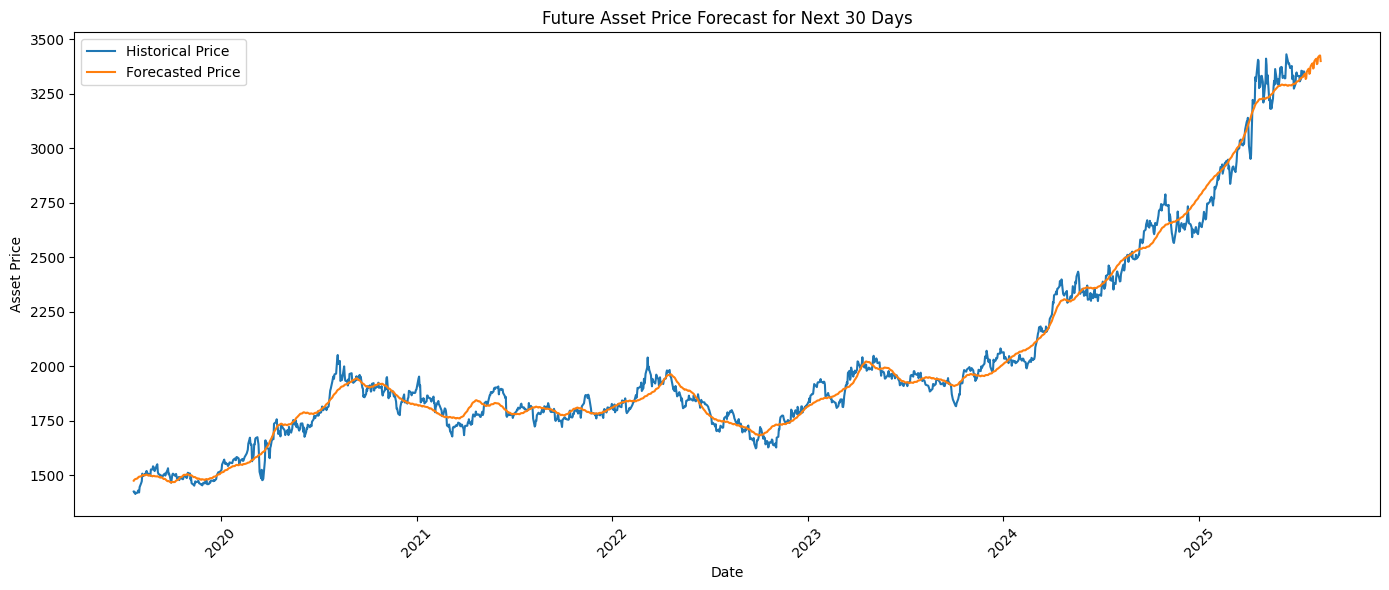

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(
    forecast_input_pdf["forecast_date"],
    forecast_input_pdf["actual_price"],
    label="Historical Price"
)

plt.plot(
    future_forecast_pdf["ds"],
    future_forecast_pdf["yhat"],
    label="Forecasted Price"
)

plt.title(f"Future Asset Price Forecast for Next {FORECAST_HORIZON_DAYS} Days")
plt.xlabel("Date")
plt.ylabel("Asset Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()